# 06 — Simplified XNAV Demo

This notebook demonstrates a simplified X-ray pulsar navigation concept using the detected pulsar period.

## Objectives

- load the preprocessed photon event dataset;
- fold photon arrival times using the detected period;
- simulate a small timing offset;
- show how a phase shift corresponds to timing error;
- convert timing error into an approximate range error.

This is an educational demonstration, not a full spacecraft navigation pipeline.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

processed_path = PROJECT_ROOT / "data" / "processed" / "vela_photons_filtered.csv"
images_dir = PROJECT_ROOT / "notebooks" / "images"

images_dir.mkdir(parents=True, exist_ok=True)

processed_path

WindowsPath('C:/Users/vi/pulsar-clean/data/processed/vela_photons_filtered.csv')

In [3]:
df_filtered = pd.read_csv(processed_path)

df_filtered.head()

,time,energy,time_rel
0,7.805337e+08,326.514008,79221.431558
1,7.805415e+08,207.780685,87021.198388
2,7.805529e+08,229.124054,98457.021602
3,7.805640e+08,271.309235,109584.648355
4,7.806201e+08,207.057602,165607.811719


In [4]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 405068 entries, 0 to 405067
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   time      405068 non-null  float64
 1   energy    405068 non-null  float64
 2   time_rel  405068 non-null  float64
dtypes: float64(3)
memory usage: 9.3 MB


## XNAV principle

Pulsars can act as stable natural clocks. If the observed pulse profile is shifted relative to an expected reference profile, this phase shift can be interpreted as a timing offset.

In a simplified one-dimensional case:

- phase shift → timing error;
- timing error → range error;
- range error ≈ speed of light × timing error.

In [5]:
detected_period = 0.0893
speed_of_light = 299_792_458  # meters per second

detected_period

0.0893

## Phase shift to timing error

A phase shift represents a fraction of the pulsar rotation period. For example, a phase shift of 0.1 means that the observed pulse arrives 10% of one pulsar period earlier or later.

In [6]:
phase_shifts = np.linspace(-0.25, 0.25, 11)

timing_errors = phase_shifts * detected_period
range_errors_km = speed_of_light * timing_errors / 1000

xnav_table = pd.DataFrame({
    "phase_shift": phase_shifts,
    "timing_error_seconds": timing_errors,
    "range_error_km": range_errors_km
})

xnav_table

,phase_shift,timing_error_seconds,range_error_km
0,-0.25,-0.022325,-6692.866625
1,-0.20,-0.017860,-5354.293300
2,-0.15,-0.013395,-4015.719975
3,-0.10,-0.008930,-2677.146650
4,-0.05,-0.004465,-1338.573325
5,0.00,0.000000,0.000000
6,0.05,0.004465,1338.573325
7,0.10,0.008930,2677.146650
8,0.15,0.013395,4015.719975
9,0.20,0.017860,5354.293300


## Simulated shifted pulse profile

To demonstrate the effect visually, a small timing offset is added to the photon arrival times. The original and shifted folded pulse profiles are then compared.

In [7]:
times = df_filtered["time_rel"].values

simulated_timing_offset = 0.002  # seconds
simulated_phase_shift = simulated_timing_offset / detected_period

reference_phases = (times % detected_period) / detected_period
shifted_phases = ((times + simulated_timing_offset) % detected_period) / detected_period

simulated_phase_shift

0.022396416573348264

In [8]:
phase_bins = 64

reference_counts, bin_edges = np.histogram(reference_phases, bins=phase_bins, range=(0, 1))
shifted_counts, _ = np.histogram(shifted_phases, bins=phase_bins, range=(0, 1))

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

profiles = pd.DataFrame({
    "phase": bin_centers,
    "reference_count": reference_counts,
    "shifted_count": shifted_counts
})

profiles.head()

,phase,reference_count,shifted_count
0,0.007812,6330,6337
1,0.023438,6329,6449
2,0.039062,6287,6277
3,0.054688,6231,6235
4,0.070312,6419,6292


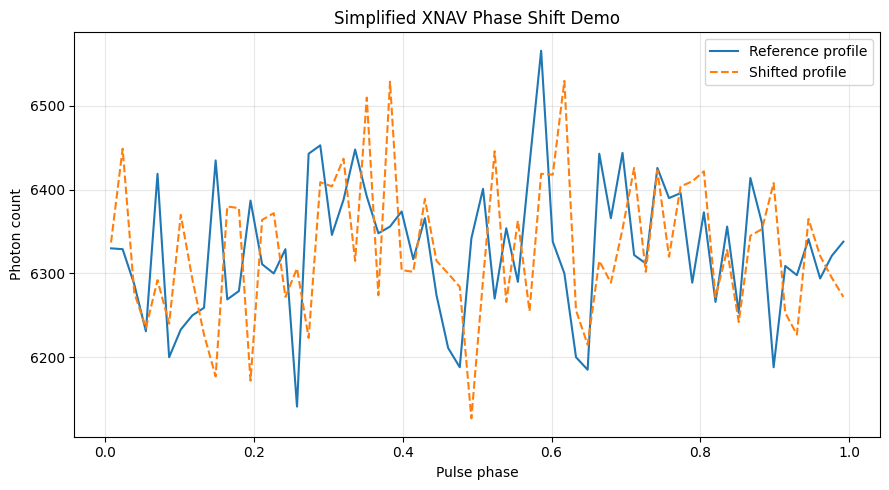

WindowsPath('C:/Users/vi/pulsar-clean/notebooks/images/06_xnav_phase_shift_demo.png')

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(profiles["phase"], profiles["reference_count"], label="Reference profile")
plt.plot(profiles["phase"], profiles["shifted_count"], linestyle="--", label="Shifted profile")
plt.xlabel("Pulse phase")
plt.ylabel("Photon count")
plt.title("Simplified XNAV Phase Shift Demo")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plot_path = images_dir / "06_xnav_phase_shift_demo.png"
plt.savefig(plot_path, dpi=150)

plt.show()

plot_path

## Range error estimate

The simulated timing offset can be converted into an approximate range error by multiplying it by the speed of light.

In [10]:
simulated_range_error_km = speed_of_light * simulated_timing_offset / 1000

print(f"Simulated timing offset: {simulated_timing_offset:.6f} seconds")
print(f"Simulated phase shift: {simulated_phase_shift:.4f}")
print(f"Approximate range error: {simulated_range_error_km:.2f} km")

Simulated timing offset: 0.002000 seconds
Simulated phase shift: 0.0224
Approximate range error: 599.58 km


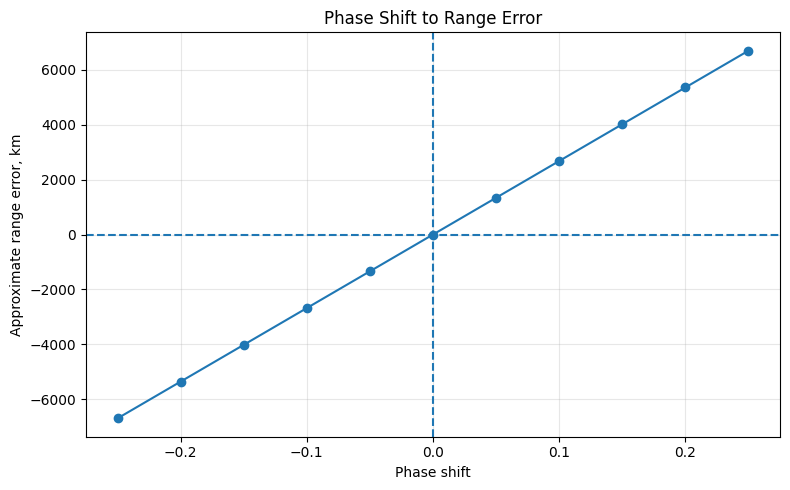

WindowsPath('C:/Users/vi/pulsar-clean/notebooks/images/06_phase_shift_to_range_error.png')

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(xnav_table["phase_shift"], xnav_table["range_error_km"], marker="o")
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Phase shift")
plt.ylabel("Approximate range error, km")
plt.title("Phase Shift to Range Error")
plt.grid(alpha=0.3)
plt.tight_layout()

plot_path = images_dir / "06_phase_shift_to_range_error.png"
plt.savefig(plot_path, dpi=150)

plt.show()

plot_path

## Summary

This simplified XNAV demonstration shows how a pulse phase shift can be interpreted as a timing offset and then converted into an approximate range error.

The example is intentionally simplified. A real XNAV system would require multiple pulsars, precise spacecraft clock modeling, barycentric corrections, relativistic corrections, orbital dynamics, uncertainty estimation, and sensor fusion.